<a href="https://colab.research.google.com/github/JaskarJeyabalan/Cat-vs-Dog-Classification/blob/main/Dog_vs_Cat_Classification_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Extracting Dataset using Kaggle API

In [1]:
# installing the Kaggle library
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Importing the Dog vs Cat Dataset from Kaggle

In [3]:
# Kaggle api
!kaggle competitions download -c dogs-vs-cats

dogs-vs-cats.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!ls

 dogs-vs-cats.zip   kaggle.json   sampleSubmission.csv	 train.zip
' jkjj'		    sample_data   train


In [5]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [6]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
import os
# counting the number of files in train folder
path, dirs, files = next(os.walk('/content/train'))
file_count = len(files)
print('Number of images: ', file_count)

Number of images:  25000


Printing the name of images

In [8]:
file_names = os.listdir('/content/train/')
print(file_names)

['cat.2993.jpg', 'cat.11255.jpg', 'dog.8464.jpg', 'dog.4401.jpg', 'cat.7017.jpg', 'cat.7300.jpg', 'cat.9955.jpg', 'cat.7765.jpg', 'cat.4284.jpg', 'dog.11558.jpg', 'dog.10675.jpg', 'dog.8318.jpg', 'dog.4275.jpg', 'cat.11927.jpg', 'cat.5185.jpg', 'dog.2767.jpg', 'dog.1721.jpg', 'cat.6270.jpg', 'cat.6150.jpg', 'dog.7025.jpg', 'cat.11903.jpg', 'dog.546.jpg', 'dog.10916.jpg', 'dog.5974.jpg', 'dog.5047.jpg', 'dog.6393.jpg', 'cat.5663.jpg', 'dog.9932.jpg', 'dog.4093.jpg', 'dog.4726.jpg', 'cat.2106.jpg', 'cat.4854.jpg', 'dog.2892.jpg', 'dog.3411.jpg', 'cat.9450.jpg', 'cat.4269.jpg', 'dog.4346.jpg', 'dog.3522.jpg', 'cat.775.jpg', 'dog.11771.jpg', 'dog.10100.jpg', 'dog.10298.jpg', 'dog.7913.jpg', 'cat.2419.jpg', 'cat.1658.jpg', 'cat.1419.jpg', 'dog.10398.jpg', 'dog.9852.jpg', 'dog.7829.jpg', 'cat.1689.jpg', 'cat.11449.jpg', 'dog.3038.jpg', 'cat.10587.jpg', 'dog.10305.jpg', 'dog.7857.jpg', 'dog.413.jpg', 'dog.11217.jpg', 'dog.7893.jpg', 'dog.10970.jpg', 'cat.1757.jpg', 'cat.11266.jpg', 'dog.5817.

Importing the Dependencies

In [9]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from google.colab.patches import cv2_imshow

Displaying the images of dogs and cats

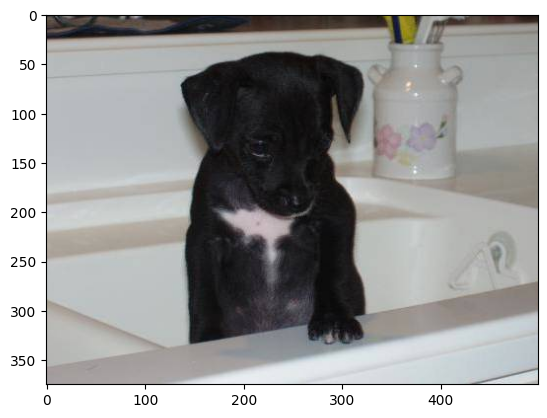

In [10]:
# display dog image
img = mpimg.imread('/content/train/dog.8298.jpg')
imgplt = plt.imshow(img)
plt.show()

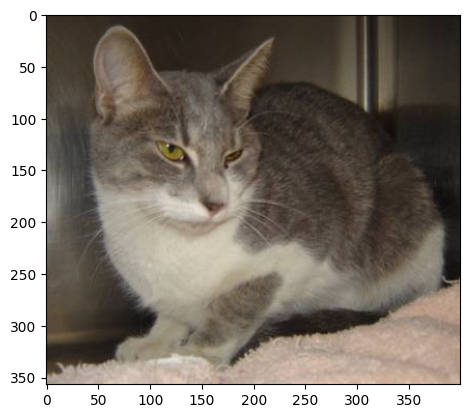

In [11]:
# display cat image
img = mpimg.imread('/content/train/cat.4352.jpg')
imgplt = plt.imshow(img)
plt.show()

In [12]:
file_names = os.listdir('/content/train/')

for i in range(5):

  name = file_names[i]
  print(name[0:3])



cat
cat
dog
dog
cat


In [13]:
file_names = os.listdir('/content/train/')

dog_count = 0
cat_count = 0

for img_file in file_names:

  name = img_file[0:3]

  if name == 'dog':
    dog_count += 1

  else:
    cat_count += 1

print('Number of dog images =', dog_count)
print('Number of cat images =', cat_count)

Number of dog images = 12500
Number of cat images = 12500


Resizing all the images

In [14]:
#creating a directory for resized images
os.mkdir('/content/image resized')

In [15]:
original_folder = '/content/train/'
resized_folder = '/content/image resized/'

for i in range(2000):

  filename = os.listdir(original_folder)[i]
  img_path = original_folder+filename

  img = Image.open(img_path)
  img = img.resize((224, 224))
  img = img.convert('RGB')

  newImgPath = resized_folder+filename
  img.save(newImgPath)

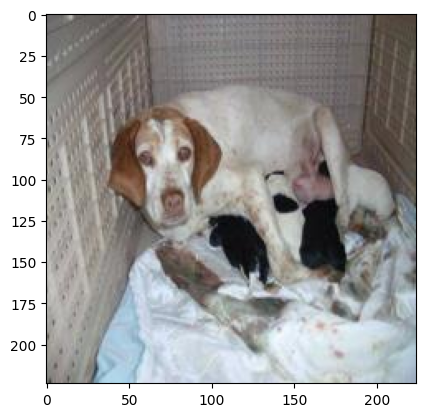

In [16]:
# display resized dog image
img = mpimg.imread('/content/image resized/dog.10060.jpg')
imgplt = plt.imshow(img)
plt.show()

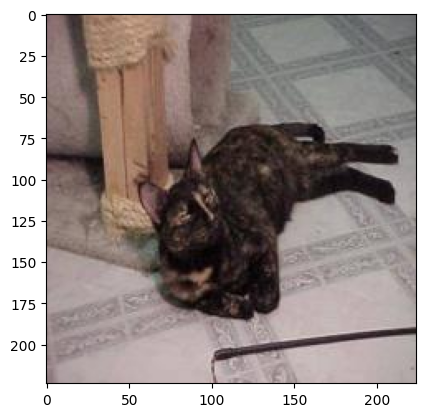

In [17]:
# display resized cat image
img = mpimg.imread('/content/image resized/cat.6054.jpg')
imgplt = plt.imshow(img)
plt.show()

**Creating labels for resized images of dogs and cats**

Cat --> 0

Dog --> 1

In [18]:
# creaing a for loop to assign labels
filenames = os.listdir('/content/image resized/')


labels = []

for i in range(2000):

  file_name = filenames[i]
  label = file_name[0:3]

  if label == 'dog':
    labels.append(1)

  else:
    labels.append(0)

In [19]:
print(filenames[0:5])
print(len(filenames))

['cat.2993.jpg', 'cat.11255.jpg', 'dog.8464.jpg', 'dog.4401.jpg', 'cat.7017.jpg']
2000


In [20]:
print(labels[0:5])
print(len(labels))

[0, 0, 1, 1, 0]
2000


In [21]:
# counting the images of dogs and cats out of 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 971 1029]


Converting all the resized images to numpy arrays

In [22]:
import cv2
import glob

In [23]:
image_directory = '/content/image resized/'
image_extension = ['png', 'jpg']

files = []

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [24]:
print(dog_cat_images)

[[[[114 109 110]
   [114 109 110]
   [113 111 111]
   ...
   [132 128 127]
   [131 127 126]
   [147 143 142]]

  [[101  96  97]
   [105 100 101]
   [110 108 108]
   ...
   [127 123 122]
   [133 129 128]
   [151 147 146]]

  [[ 93  88  89]
   [ 98  93  94]
   [104 102 102]
   ...
   [131 127 126]
   [133 129 128]
   [144 140 139]]

  ...

  [[135 130 129]
   [126 121 120]
   [119 114 113]
   ...
   [ 87  86  82]
   [ 83  81  80]
   [ 91  89  88]]

  [[135 130 129]
   [128 123 122]
   [126 121 120]
   ...
   [115 114 110]
   [ 96  94  93]
   [ 96  97  95]]

  [[129 124 123]
   [127 122 121]
   [129 124 123]
   ...
   [123 122 118]
   [ 91  92  90]
   [ 89  90  88]]]


 [[[ 55  59  60]
   [ 56  60  61]
   [ 57  61  62]
   ...
   [ 56  56  56]
   [ 59  59  59]
   [ 61  61  61]]

  [[ 54  58  59]
   [ 55  59  60]
   [ 56  60  61]
   ...
   [ 56  56  56]
   [ 58  58  58]
   [ 60  60  60]]

  [[ 53  57  58]
   [ 53  57  58]
   [ 54  58  59]
   ...
   [ 56  56  56]
   [ 57  57  57]
   [ 58  58

In [25]:
type(dog_cat_images)

numpy.ndarray

In [26]:
print(dog_cat_images.shape)

(2000, 224, 224, 3)


In [27]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [28]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [29]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


1600 --> training images

400 --> test images

In [30]:
# scaling the data
X_train_scaled = X_train/255

X_test_scaled = X_test/255

In [31]:
print(X_train_scaled)

[[[[0.88627451 0.71764706 0.54901961]
   [0.89411765 0.72941176 0.56078431]
   [0.89803922 0.74509804 0.56862745]
   ...
   [0.76862745 0.88627451 0.95294118]
   [0.5254902  0.64705882 0.72941176]
   [0.29019608 0.41176471 0.50196078]]

  [[0.96862745 0.8        0.63137255]
   [0.96470588 0.8        0.63137255]
   [0.94901961 0.79607843 0.61960784]
   ...
   [0.63137255 0.74901961 0.81568627]
   [0.44705882 0.56862745 0.65098039]
   [0.11764706 0.23921569 0.32941176]]

  [[0.9372549  0.76862745 0.6       ]
   [0.92941176 0.76470588 0.59607843]
   [0.91372549 0.76078431 0.58431373]
   ...
   [0.4        0.51764706 0.58431373]
   [0.41176471 0.5372549  0.61176471]
   [0.42745098 0.54901961 0.63137255]]

  ...

  [[0.79607843 0.74901961 0.70196078]
   [0.71372549 0.66666667 0.61960784]
   [0.68627451 0.63921569 0.59215686]
   ...
   [0.62745098 0.56862745 0.49411765]
   [0.65098039 0.59215686 0.51764706]
   [0.68627451 0.62745098 0.55294118]]

  [[0.77254902 0.7254902  0.67843137]
   [0.7

**Building the Neural Network**

In [32]:
!pip install tf_keras

In [33]:
import tensorflow as tf
import tf_keras as keras
import tensorflow_hub as hub

/usr/local/lib/python3.13/dist-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [34]:
mobilenet_model = "https://tfhub.dev/google/tf2-preview/mobilenet_v2/feature_vector/4"

pretrained_model = hub.KerasLayer(
    mobilenet_model,
    input_shape=(224, 224, 3),
    trainable=False
)

num_of_classes = 2

inputs = keras.Input(shape=(224, 224, 3))
x = pretrained_model(inputs)
outputs = keras.layers.Dense(num_of_classes)(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 keras_layer (KerasLayer)    (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [35]:
model.compile(
    optimizer = 'adam',
    loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['acc']
)

In [36]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 80s 1s/step - loss: 0.2714 - acc: 0.8756
Epoch 2/5
50/50 [==============================] - 65s 1s/step - loss: 0.0810 - acc: 0.9756
Epoch 3/5
50/50 [==============================] - 64s 1s/step - loss: 0.0559 - acc: 0.9856
Epoch 4/5
50/50 [==============================] - 66s 1s/step - loss: 0.0444 - acc: 0.9869
Epoch 5/5
50/50 [==============================] - 57s 1s/step - loss: 0.0364 - acc: 0.9906


In [37]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

13/13 [==============================] - 15s 1s/step - loss: 0.0687 - acc: 0.9750
Test Loss = 0.06865669041872025
Test Accuracy = 0.9750000238418579


**Predictive System**

Path of the image to be predicted: /content/image resized/cat.10013.jpg


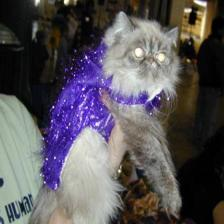

1/1 [==============================] - 1s 620ms/step
[[ 0.30016923 -1.8121048 ]]
0
The image represents a Cat


In [38]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Cat')

else:
  print('The image represents a Dog')